# Figure 2: WGAN-GP Training Dynamics and Evaluation of Synthetic Promoters (SPs)

This notebook generates the panels for **Figure 2**, which illustrate the training stability of the WGAN-GP model and thoroughly evaluate the similarity between Synthetic Promoters (SPs) and Natural Promoters (NPs).

The analyses are organized into three main sections:

1.  **WGAN-GP Training Dynamics**:
    *   **Discriminator Validation Loss**: Monitoring convergence across hyperparameters.
    *   **K-mer Frequency Learning**: Tracking the improvement of $R^2$ scores for 4, 5, and 6-mer frequencies during training.
    *   **Sequence Diversity Evolution**: Monitoring the changes in Jaccard Distance, Levenshtein Distance, and GC Content across 100 to 100k iterations to ensure diversity is maintained.

2.  **Model Selection**:
    *   **Activity Distribution**: Comparing the predicted biological activity (log2 enrichment) distribution of promoters generated by the model at iteration 54,000 against natural promoters.

3.  **Comprehensive Feature Evaluation**:
    *   **K-mer Correlation**: A scatter plot comparing 6-mer frequencies between **all** Natural Promoters and Synthetic Promoters, highlighting TATA-box conservation.
    *   **Diversity & Composition**: Detailed boxplot comparisons of sequence distance metrics and GC content between the final generated set and natural promoters.
    *   **DNA Shape Features**: Comparative density distributions of structural features (**MGW**, **ProT**, **Roll**, **HelT**) for Native, GAN-generated, and Random sequences.

## Import Required Packages and Configure Environment

In [1]:
import os
# Specify CUDA device before importing tensorflow to ensure it takes effect
os.environ["CUDA_VISIBLE_DEVICES"] = '1'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import random
import importlib
from functools import reduce

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow import keras

# Custom utils
import utils
from utils import accumulate_kmer_frequencies, one_hot_encode, suppress_tf_warnings, gc_content

# Configure Plotting Style
# Font settings
font_path = '/home/xlxiang/miniconda3/ARIAL.TTF'
if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = 'Arial'
else:
    print(f"Warning: Font file not found at {font_path}")

# Border width settings
plt.rcParams['axes.linewidth'] = 0.75

# Suppress TensorFlow warnings
suppress_tf_warnings()

## 1. WGAN-GP Training Dynamics

### Discriminator Validation Loss
Monitoring the discriminator validation loss to assess convergence and training stability across different hyperparameters.

['z_dim_30_gen_dim_50_disc_dim_50', 'z_dim_30_gen_dim_100_disc_dim_100', 'z_dim_30_gen_dim_150_disc_dim_150', 'z_dim_50_gen_dim_50_disc_dim_50', 'z_dim_50_gen_dim_100_disc_dim_100', 'z_dim_50_gen_dim_150_disc_dim_150', 'z_dim_70_gen_dim_50_disc_dim_50', 'z_dim_70_gen_dim_100_disc_dim_100', 'z_dim_70_gen_dim_150_disc_dim_150', 'z_dim_100_gen_dim_200_disc_dim_200']


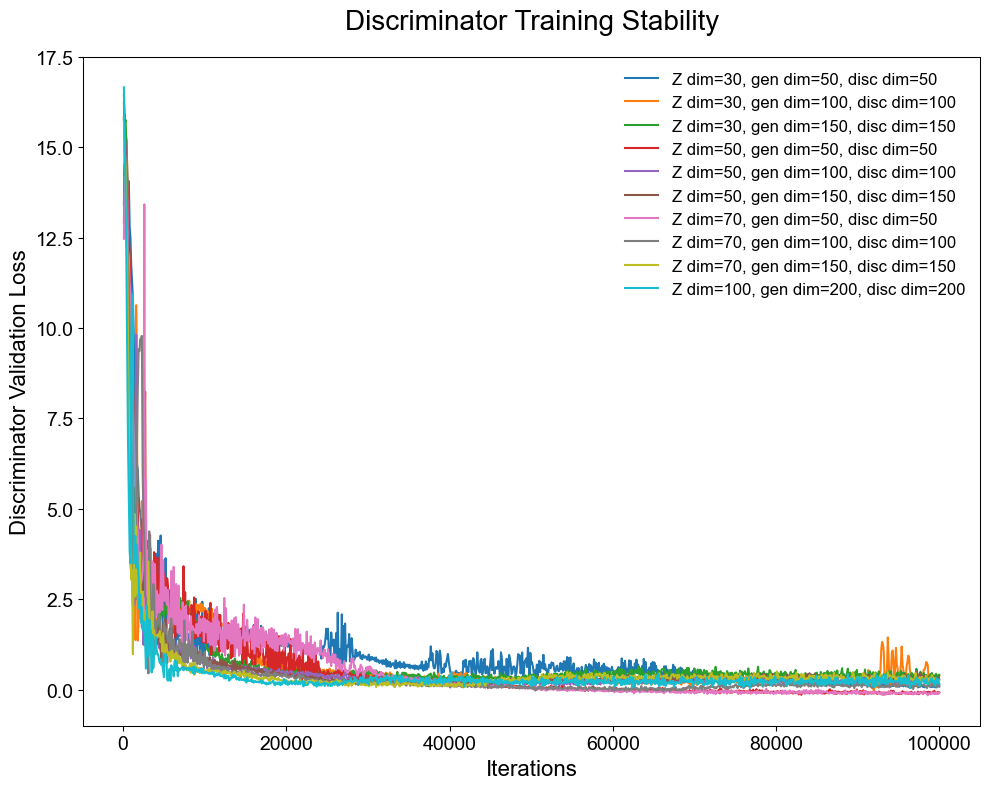

In [2]:
all_dir_list = []
for a in [30,50,70]:
    for b in [50,100,150]:
        all_dir_list.append('z_dim_%s_gen_dim_%s_disc_dim_%s'%(a,b,b))
all_dir_list.append('z_dim_100_gen_dim_200_disc_dim_200')
print(all_dir_list)

plt.figure(figsize=(10, 8))
for i in all_dir_list:
    loss = pd.read_csv('../wgan-gp/%s/valid_disc_diff.csv'%i,header=None)
    label= ''.join(['Z dim=',i.split('_')[2],', gen dim=',i.split('_')[-1],', disc dim=',i.split('_')[-1]])
    sns.lineplot(x=loss[0], y=-loss[1],linewidth=1.5,label=label)

plt.yticks(size = 14)
plt.xticks(size = 14)
plt.legend(prop={'size': 12}, frameon=False)
plt.xlabel("Iterations", fontdict={'size': 16, 'weight':'bold'})
plt.ylabel("Discriminator Validation Loss", fontdict={'size': 16, 'weight':'bold'})
plt.title("Discriminator Training Stability", fontsize=20, fontweight='bold', pad=20)

plt.tight_layout()
#plt.savefig('valid_loss.svg',dpi=1000)
plt.show()

### K-mer Frequency R2 Score Growth
Evaluating the correlation (R2 score) of k-mer frequencies between generated sequences and natural sequences during training to measure how well the model learns sequence motifs.

4-mer Test Set R2: 0.9784
5-mer Test Set R2: 0.9531
6-mer Test Set R2: 0.8928


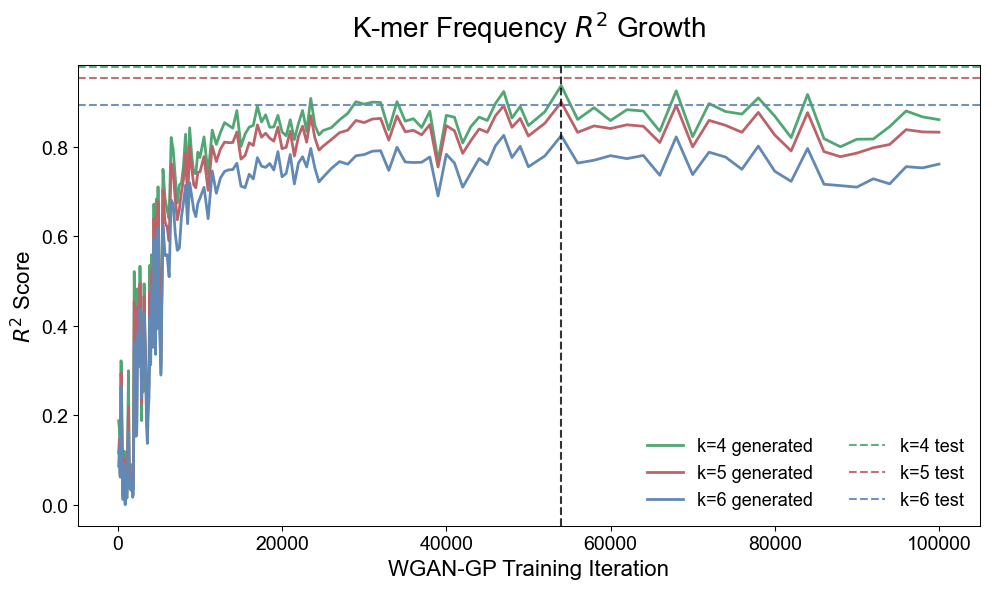

In [3]:
# Set random seed for reproducibility
seed = 2024
random.seed(seed)
np.random.seed(seed)

# Define sample size and k-mer values to check
num_samples = 640
k_mer_values = [4, 5, 6]

# Load dataset
data = pd.read_excel('../data/Natural_promoters.xlsx')
data_train = data[data.dataset == 'training set']
data_test = data[data.dataset == 'test set']

# Prepare sequences
train_seq = list(data_train.sequence)
# Randomly sample sequences from the test set
test_seq = random.sample(list(data_test.sequence), num_samples)

r2_results = {}

# Calculate correlation of k-mer frequencies between training and test sets
# This serves as the benchmark/ceiling for the generated sequences
for k in k_mer_values:
    accumulated_vector_train = accumulate_kmer_frequencies(train_seq, k)
    accumulated_vector_test = accumulate_kmer_frequencies(test_seq, k)
    
    # Calculate R-squared value (using squared correlation coefficient)
    r2 = np.corrcoef(accumulated_vector_train, accumulated_vector_test)[0, 1]**2
    r2_results[k] = r2

# Print the results for each k-mer
for k, r2 in r2_results.items():
    print(f'{k}-mer Test Set R2: {r2:.4f}')

# Load and Plot Pre-calculated Data
file_path = './data_for_plot/train_gen.txt'
if os.path.exists(file_path):
    r2_df = pd.read_csv(file_path, sep='\t', index_col=0)
    
    # Initialize Plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare X-axis data (iterations)
    x_values = [int(i) for i in r2_df.index]
    
    # Define colors for k=4, 5, 6 (Green, Red, Blue) matching the publication style
    colors = {4: '#51a773', 5: '#bc6269', 6: '#6289b5'}
    
    # 1. Plot Generated Sequences R2 (Solid Lines)
    for k in k_mer_values:
        col_name = str(k)
        if col_name in r2_df.columns:
            ax.plot(x_values, r2_df[col_name], label=f'k={k} generated', color=colors[k], linewidth=2)
            
    # 2. Plot Test Set R2 Benchmark (Dashed Lines)
    for k in k_mer_values:
         if k in r2_results:
            ax.axhline(y=r2_results[k], color=colors[k], linestyle='--', label=f'k={k} test', linewidth=1.5, alpha=0.9)

    # 3. Add Vertical Line at 54000 (Model Checkpoint)
    ax.axvline(x=54000, color='black', linestyle='--', linewidth=1.5, alpha=0.8)

    # Styling and Labels
    ax.set_xlabel('WGAN-GP Training Iteration', fontsize=16, fontweight='bold')
    ax.set_ylabel(r'$R^2$ Score', fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_title("K-mer Frequency $R^2$ Growth", fontsize=20, fontweight='bold', pad=20)
    
    # Configure Legend (Two Columns)
    ax.legend(ncol=2, prop={'size': 13}, loc='lower right', frameon=False)
    
    # Clean up layout
    plt.tight_layout()
    plt.show()
else:
    print(f"Error: Pre-calculated data file not found at {file_path}. Please ensure the file exists.")

### Sequence Diversity and GC Content Monitoring
Tracking Jaccard distance, Levenshtein distance, and GC content across training iterations to ensure the model maintains diversity and matches natural properties.

**Note:** You need to run `python jaccard_levenshtein_distance_train.py` beforehand to calculate the distances between SPs and NPs during the iterations.

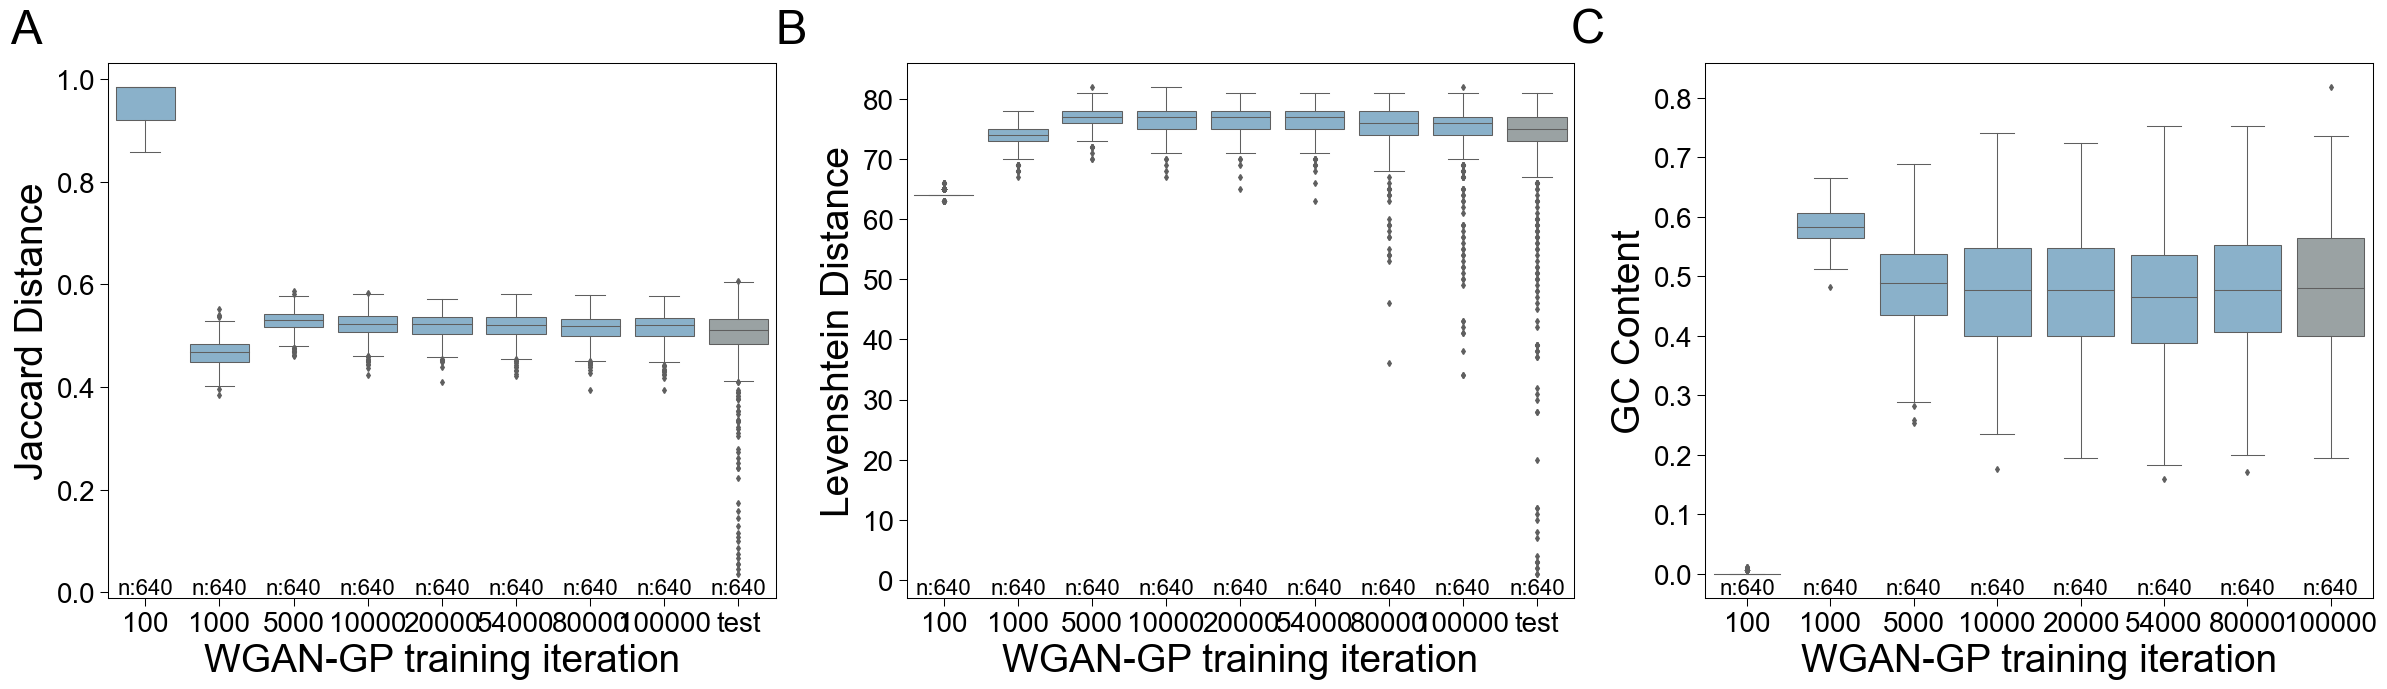

In [4]:
# Set global border width
plt.rcParams['axes.linewidth'] = 0.75

seed = 2024
random.seed(seed)
np.random.seed(seed)

iterations = ['100','1000','5000', '10000','20000','54000','80000','100000']
jaccard_file = './data_for_plot/result_min_Jaccard.csv'
levenshtein_file = './data_for_plot/result_min_Levenshtein.csv'

if os.path.exists(jaccard_file):
    jaccard_df = pd.read_csv(jaccard_file)
else:
    jaccard_df = pd.DataFrame()

if os.path.exists(levenshtein_file):
    levenshtein_df = pd.read_csv(levenshtein_file)
else:
    levenshtein_df = pd.DataFrame()

# Calculate GC df
gc_df = pd.DataFrame()
for it in iterations:
    gc_values = []
    # Adjust path if necessary, assuming relative path from notebook
    sample_file = f'../wgan-gp/z_dim_100_gen_dim_200_disc_dim_200/samples/samples_{it}'
    if os.path.exists(sample_file):
        with open(sample_file, 'r') as f:
            for line in f:
                if line.strip(): gc_values.append(gc_content(line.strip()))
        gc_df[it] = gc_values

nat_promoters_file = '../data/Natural promoters.xlsx'
if os.path.exists(nat_promoters_file):
    data_nat = pd.read_excel(nat_promoters_file)
    data_test = data_nat[data_nat.dataset == 'test set']
    test_sample_seqs = random.sample(list(data_test.sequence), 640)
    gc_df['test'] = [gc_content(seq) for seq in test_sample_seqs]

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Create a palette large enough (iterations + test)
palette_blue = ["#7FB3D5"] * len(iterations) + ["#99A3A4"]

# Helper function to add 'n=...' text
def add_n_labels(ax, data_df):
    if data_df.empty: return
    # Assuming standard columns layout matching x-axis ticks
    labels = [label.get_text() for label in ax.get_xticklabels()]
    counts = []
    for label in labels:
        if label in data_df.columns:
            # Drop NaNs to get actual count if needed, or just length
            n = data_df[label].dropna().shape[0]
            counts.append(n)
        else:
            counts.append(0) # Or handle appropriately
            
    # Add text above x-axis ticks
    ymin, ymax = ax.get_ylim()
    y_range = ymax - ymin
    
    for i, count in enumerate(counts):
        ax.text(i, ymin, f'n:{count}', ha='center', va='bottom', fontsize=16, fontname='Arial', color='black')

# Subplot E: Jaccard
if not jaccard_df.empty:
    sns.boxplot(data=jaccard_df, palette=palette_blue[:len(jaccard_df.columns)], linewidth=0.75, fliersize=3, ax=axes[0])
    axes[0].set_ylabel('Jaccard Distance', fontsize=28, fontname='Arial')
    axes[0].set_xlabel('WGAN-GP training iteration', fontsize=28, fontname='Arial')
    axes[0].tick_params(axis='both', labelsize=20, width=0.75) 
    add_n_labels(axes[0], jaccard_df)

# Subplot F: Levenshtein
if not levenshtein_df.empty:
    sns.boxplot(data=levenshtein_df, palette=palette_blue[:len(levenshtein_df.columns)], linewidth=0.75, fliersize=3, ax=axes[1])
    axes[1].set_ylabel('Levenshtein Distance', fontsize=28, fontname='Arial')
    axes[1].set_xlabel('WGAN-GP training iteration', fontsize=28, fontname='Arial')
    axes[1].tick_params(axis='both', labelsize=20, width=0.75)
    add_n_labels(axes[1], levenshtein_df)

# Subplot G: GC Content
if not gc_df.empty:
    colors = ["#7FB3D5"] * (len(gc_df.columns) - 1) + ["#99A3A4"] 
    sns.boxplot(data=gc_df, palette=colors, linewidth=0.75, fliersize=3, ax=axes[2])
    axes[2].set_ylabel('GC Content', fontsize=28, fontname='Arial')
    axes[2].set_xlabel('WGAN-GP training iteration', fontsize=28, fontname='Arial')
    axes[2].tick_params(axis='both', labelsize=20, width=0.75)
    add_n_labels(axes[2], gc_df)

# Add A, B, C labels
labels = ['A', 'B', 'C']
positions = [(-0.1, 1.02), (-0.15, 1.02), (-0.15, 1.02)]

for i, ax in enumerate(axes):
    x_pos, y_pos = positions[i]
    ax.text(x_pos, y_pos, labels[i], transform=ax.transAxes, fontsize=34, fontweight='bold', va='bottom', ha='right', fontname='Arial')

    # Set linewidth for the spines
    for spine in ax.spines.values():
        spine.set_linewidth(0.75)
        spine.set_color('black')
    
    # Ensure standard ticks look
    ax.tick_params(width=0.75, length=6)

plt.tight_layout()
plt.show()

## 2. Model Selection and Evaluation (Iteration 54,000)
Based on the convergence metrics above, **iteration 54,000** was selected as the optimal checkpoint.

### Predicted Activity Distribution
Comparing the predicted activity distributions (log2 enrichment) of 76,851 synthetic promoters generated at iteration 54,000 against natural promoters.

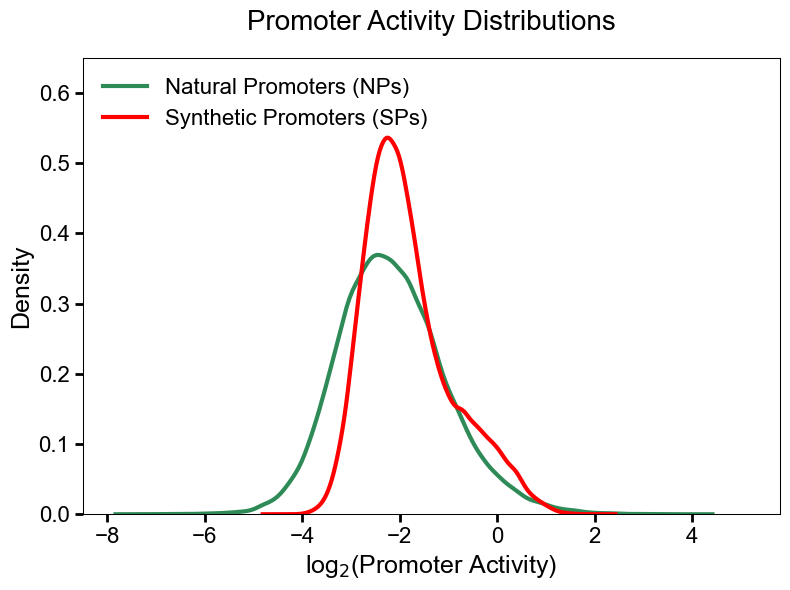

In [5]:
# Load model
model_path = '../data/predictor.h5'
if not os.path.exists(model_path):
    model_path = '/home/xlxiang/TargetGAN-main/data/predictor.h5'
model = keras.models.load_model(model_path)

# Load Data
data_np = pd.read_excel('../data/Natural_promoters.xlsx')
activities_np = data_np['enrichment'].values

sp_file_path = '../samples/WGAN-GP-54000-76851.txt'
data_sp = pd.read_csv(sp_file_path, header=None)
sp_sequences = data_sp[0].tolist()

sp_onehot = np.array([one_hot_encode(seq) for seq in sp_sequences])
predicted_activities_sp = model.predict(sp_onehot, verbose=0)
activities_sp = np.squeeze(predicted_activities_sp)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

sns.kdeplot(activities_np, color="seagreen", linewidth=3, label='Natural Promoters (NPs)', ax=ax)
sns.kdeplot(activities_sp, color="red", linewidth=3, label='Synthetic Promoters (SPs)', ax=ax)

# Styling
ax.set_title('Promoter Activity Distributions', fontsize=20, fontweight='bold', pad=20)
ax.set_xlabel(r'log$_2$(Promoter Activity)', fontsize=18)
ax.set_ylabel('Density', fontsize=18)
ax.set_xlim(-8.5, 5.8)
ax.set_ylim(0, 0.65)
ax.tick_params(axis='both', which='major', labelsize=16, width=2, length=6)
legend = ax.legend(frameon=False, fontsize=16, loc='upper left')

plt.tight_layout()
plt.show()

## 3. Comprehensive Feature Evaluation
A detailed comparison of sequence grammar and structural features between synthetic promoters (SPs) and natural promoters (NPs).

### K-mer Frequency Correlation (Detailed)
Scatter plot comparison of 6-mer frequencies between the final synthetic dataset and the full natural dataset, highlighting key TATA-box motifs.

Loaded 76851 Natural Promoters.
Loaded 76851 Synthetic Promoters from ../samples/WGAN-GP-54000-76851.txt.
Calculating 6-mer frequencies...
Pearson Correlation Coefficient: 0.9472


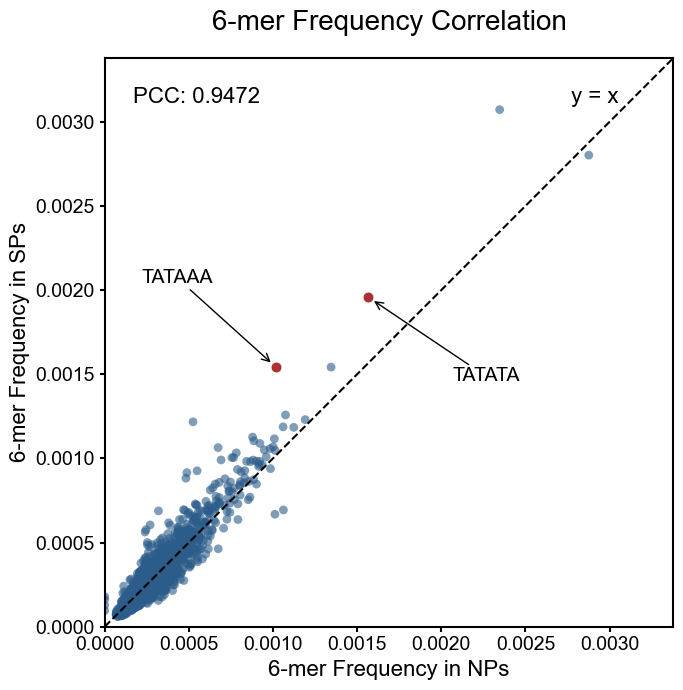

In [6]:
# 1. Load Reference Data (All Natural Promoters)
data_path = '../data/Natural_promoters.xlsx'
if not os.path.exists(data_path):
    data_path = '../data/Natural promoters.xlsx'

try:
    data = pd.read_excel(data_path)
    natural_seqs = list(data['sequence'])
    print(f"Loaded {len(natural_seqs)} Natural Promoters.")
except Exception as e:
    print(f"Error loading Natural promoters: {e}")
    natural_seqs = []

# 2. Load Generated Data (All Synthetic Promoters from 54000 iteration)
# Use the full generated set (approx 76k) instead of the small training sample batch (640)
generated_seqs = []
sp_file_path = '../samples/WGAN-GP-54000-76851.txt'

if os.path.exists(sp_file_path):
    try:
        # Check format implicitly by reading first line or using pandas robustness
        # Assuming it's a simple text file or single column CSV
        try:
            # Try reading as simple text list first (common format for generated sequences)
            with open(sp_file_path, 'r') as f:
                generated_seqs = [line.strip() for line in f if line.strip()]
            
            # If the first line looks like a CSV index or header, switch to pandas
            if len(generated_seqs) > 0 and ',' in generated_seqs[0]:
                 df_sp = pd.read_csv(sp_file_path, header=None)
                 generated_seqs = df_sp[0].tolist()
        except:
             # Fallback to pandas
             df_sp = pd.read_csv(sp_file_path, header=None)
             generated_seqs = df_sp[0].tolist()
             
        print(f"Loaded {len(generated_seqs)} Synthetic Promoters from {sp_file_path}.")
    except Exception as e:
        print(f"Error loading Synthetic promoters: {e}")
else:
    print(f"Error: Target file {sp_file_path} not found. Comparison requires the full synthetic set.")

if len(natural_seqs) > 0 and len(generated_seqs) > 0:
    # Calculate 6-mer Frequencies
    k = 6
    print(f"Calculating {k}-mer frequencies...")
    accumulated_vector_natural = accumulate_kmer_frequencies(natural_seqs, k)
    accumulated_vector_generated = accumulate_kmer_frequencies(generated_seqs, k)

    # Calculate Pearson Correlation
    pcc, _ = pearsonr(accumulated_vector_natural, accumulated_vector_generated)
    print(f"Pearson Correlation Coefficient: {pcc:.4f}")

    # Identify indices for TATA boxes
    bases = ['A', 'T', 'C', 'G']
    kmer_all = reduce(lambda x,y: [i+j for i in x for j in y], [bases] * k)
    idx_tataaa = kmer_all.index('TATAAA')
    idx_tatata = kmer_all.index('TATATA')

    # Plotting
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_aspect('equal')

    # Scatter Plot
    # Increased point size for better visibility
    ax.scatter(accumulated_vector_natural, accumulated_vector_generated, 
            s=40, c='#2b5c8a', alpha=0.6, edgecolors='none', label='6-mers')

    # Diagonal Line
    limit = max(max(accumulated_vector_natural), max(accumulated_vector_generated)) * 1.1
    # Check original limit was 0.0035, stick close if appropriate, or dynamic
    if limit > 0.005: limit = 0.0035 
    
    ax.plot([0, limit], [0, limit], 'k--', linewidth=1.5, label='y = x')

    # Highlight TATA
    highlight_color = '#a83232'
    ax.scatter(accumulated_vector_natural[idx_tataaa], accumulated_vector_generated[idx_tataaa], 
            s=60, c=highlight_color, zorder=10, edgecolors='white', linewidth=0.5)
    ax.scatter(accumulated_vector_natural[idx_tatata], accumulated_vector_generated[idx_tatata], 
            s=60, c=highlight_color, zorder=10, edgecolors='white', linewidth=0.5)

    # Annotations
    ax.text(0.05, 0.92, f'PCC: {pcc:.4f}', transform=ax.transAxes, fontsize=16, fontweight='bold')
    ax.text(0.82, 0.92, 'y = x', transform=ax.transAxes, fontsize=16)

    # Arrows (Adjust positions based on data if needed, using safe original offsets)
    # TATAAA
    ax.annotate('TATAAA', 
                xy=(accumulated_vector_natural[idx_tataaa], accumulated_vector_generated[idx_tataaa]), 
                xytext=(accumulated_vector_natural[idx_tataaa] - 0.0008, accumulated_vector_generated[idx_tataaa] + 0.0005),
                fontsize=14, fontweight='bold',
                arrowprops=dict(facecolor='black', arrowstyle='->', shrinkA=0, shrinkB=5))

    # TATATA
    ax.annotate('TATATA', 
                xy=(accumulated_vector_natural[idx_tatata], accumulated_vector_generated[idx_tatata]), 
                xytext=(accumulated_vector_natural[idx_tatata] + 0.0005, accumulated_vector_generated[idx_tatata] - 0.0005),
                fontsize=14, fontweight='bold',
                arrowprops=dict(facecolor='black', arrowstyle='->', shrinkA=0, shrinkB=5))

    # Labels and Title
    ax.set_xlim(0, limit)
    ax.set_ylim(0, limit)
    ax.set_xlabel('6-mer Frequency in NPs', fontsize=16, fontweight='bold')
    ax.set_ylabel('6-mer Frequency in SPs', fontsize=16, fontweight='bold')
    # Removed title as per potential publication style preference, or keep if requested. Keeping based on previous edits.
    ax.set_title('6-mer Frequency Correlation', fontsize=20, fontweight='bold', pad=20)

    ax.tick_params(width=1.5, labelsize=14)
    # Ensure borders (spines) are visible and correct width
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)

    plt.tight_layout()
    plt.savefig('./data_for_plot/kmer_correlation.svg', dpi=1000)
    plt.show()

### Sequence Diversity and Composition Comparison
Distributions of Jaccard distance, Levenshtein distance, and GC content for the final synthetic set compared to natural promoters.

**Note:** You need to run `python jaccard_levenshtein_distance_GAN_Targetgan.py` beforehand to calculate the distances between WGAN-GP generated promoters and NPs.

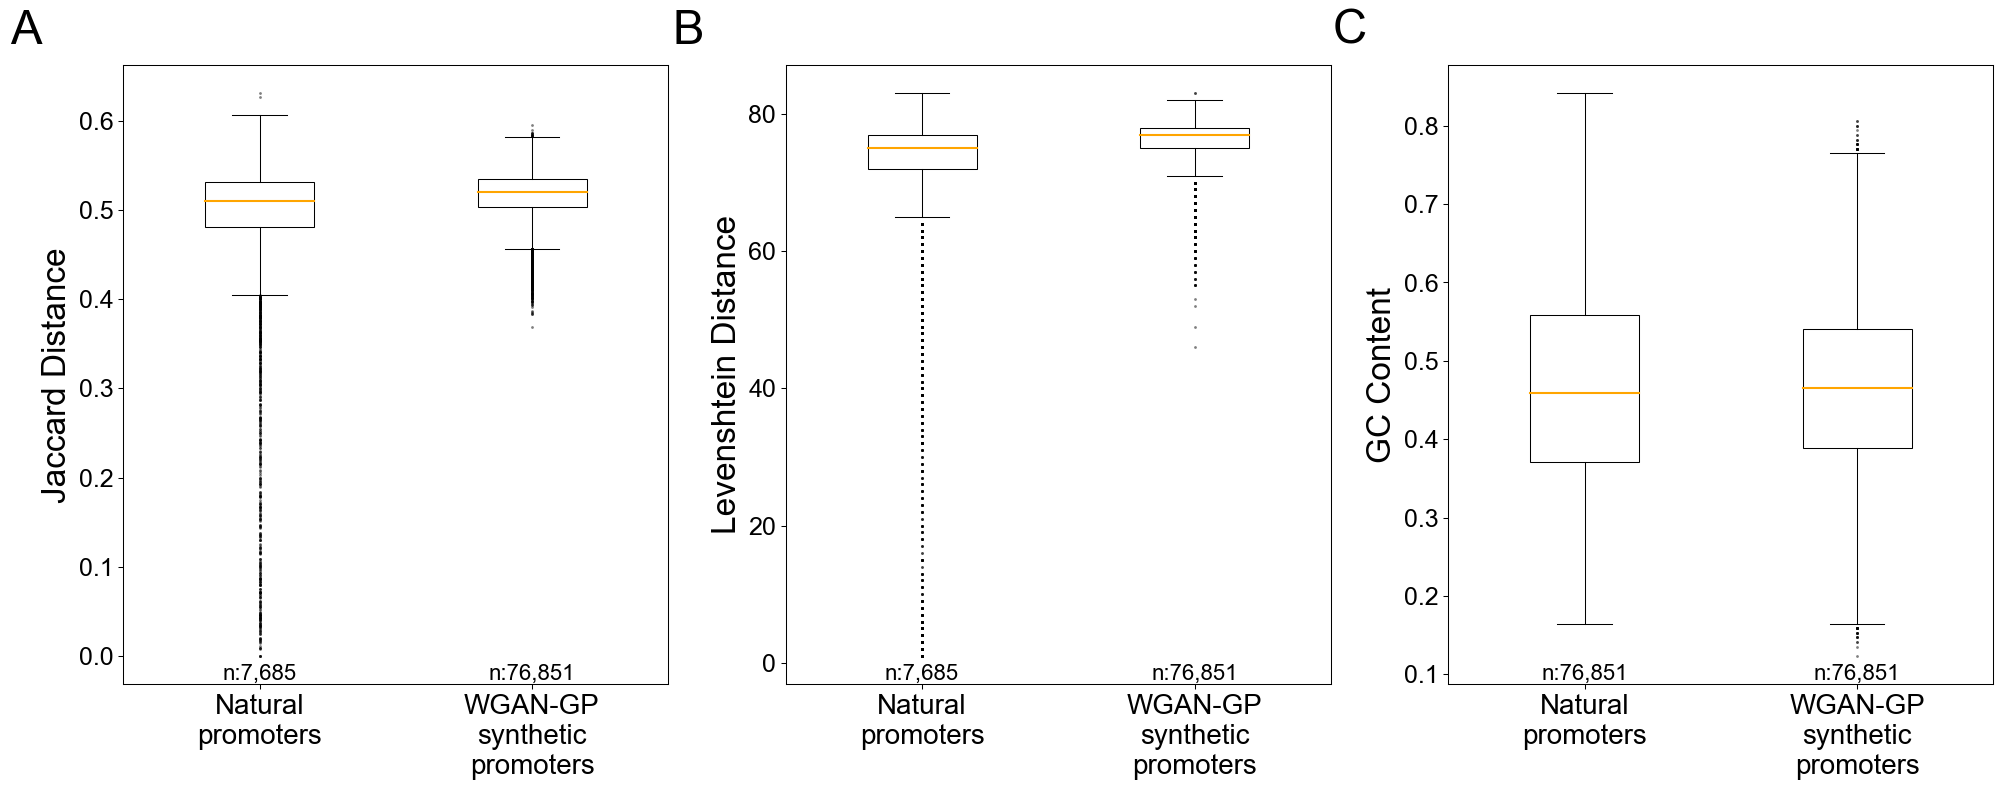

In [7]:
# Configuration
save_dir = './data_for_plot'

# Load Data
# (1) Jaccard & Levenshtein
test_jaccard = np.load(os.path.join(save_dir, 'test_jaccard.npy'))
wgan_jaccard = np.load(os.path.join(save_dir, 'wgan_jaccard.npy'))
test_levenshtein = np.load(os.path.join(save_dir, 'test_levenshtein.npy'))
wgan_levenshtein = np.load(os.path.join(save_dir, 'wgan_levenshtein.npy'))

# (2) GC Content
def get_gc_list(sequences):
    return [gc_content(seq) for seq in sequences]

# Natural Promoters (ALL)
nat_file = '../data/Natural promoters.xlsx'
if not os.path.exists(nat_file): 
    nat_file = '/home/xlxiang/TargetGAN-main/data/Natural_promoters.xlsx'

try:
    df_nat = pd.read_excel(nat_file)
    nat_seqs = df_nat['sequence'].tolist()
except:
    print("Error loading Natural promoters xlsx, using dummy data for GC")
    nat_seqs = []

# WGAN Promoters (From Excel)
wgan_file_xlsx = '/home/xlxiang/TargetGAN-main/data/WGAN_GP_gen_pro.xlsx'
try:
    if os.path.exists(wgan_file_xlsx):
        df_wgan = pd.read_excel(wgan_file_xlsx)
        # Using 'sequence' column based on user instruction
        wgan_seqs = df_wgan['sequence'].dropna().tolist()
    else:
        print(f"Error: WGAN excel file not found at {wgan_file_xlsx}")
        wgan_seqs = []
except Exception as e:
    print(f"Error loading WGAN sequences from excel: {e}")
    wgan_seqs = []

if not wgan_seqs and os.path.exists('../samples/WGAN-GP-54000-76851.txt'):
     try:
         df_wgan_txt = pd.read_csv('../samples/WGAN-GP-54000-76851.txt', header=None)
         wgan_seqs = df_wgan_txt[0].tolist()
     except: pass


nat_gc = get_gc_list(nat_seqs)
wgan_gc = get_gc_list(wgan_seqs)

# Comparisons Dataframes
df_jaccard = pd.DataFrame({
    'Value': np.concatenate([test_jaccard, wgan_jaccard]),
    'Type': ['Natural\npromoters'] * len(test_jaccard) + ['WGAN-GP\nsynthetic\npromoters'] * len(wgan_jaccard)
})

df_lev = pd.DataFrame({
    'Value': np.concatenate([test_levenshtein, wgan_levenshtein]),
    'Type': ['Natural\npromoters'] * len(test_levenshtein) + ['WGAN-GP\nsynthetic\npromoters'] * len(wgan_levenshtein)
})

df_gc = pd.DataFrame({
    'Value': np.concatenate([nat_gc, wgan_gc]),
    'Type': ['Natural\npromoters'] * len(nat_gc) + ['WGAN-GP\nsynthetic\npromoters'] * len(wgan_gc)
})

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

metrics = [
    (df_jaccard, 'Jaccard Distance', axes[0], [len(test_jaccard), len(wgan_jaccard)]),
    (df_lev, 'Levenshtein Distance', axes[1], [len(test_levenshtein), len(wgan_levenshtein)]),
    (df_gc, 'GC Content', axes[2], [len(nat_gc), len(wgan_gc)])
]

labels_abc = ['A', 'B', 'C']

for i, (data, ylabel, ax, counts) in enumerate(metrics):
    sns.boxplot(data=data, x='Type', y='Value', ax=ax, width=0.4, 
                boxprops=dict(facecolor='white', edgecolor='black', linewidth=0.75),
                whiskerprops=dict(color='black', linewidth=0.75),
                capprops=dict(color='black', linewidth=0.75),
                medianprops=dict(color='orange', linewidth=1.5),
                flierprops=dict(marker='o', markersize=2, markerfacecolor='black', markeredgecolor='none', alpha=0.5))
    
    ax.set_xlabel("", fontsize=0)
    ax.set_ylabel(ylabel, fontsize=24, fontname='Arial', color='black')
    
    ax.tick_params(axis='x', labelsize=20, width=0.75)
    ax.tick_params(axis='y', labelsize=18, width=0.75)
    
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname('Arial')
        
    for spine in ax.spines.values():
        spine.set_linewidth(0.75)
        spine.set_color('black')
        
    ymin, ymax = ax.get_ylim()
    for idx, count in enumerate(counts):
        ax.text(idx, ymin, f"n:{count:,}", ha='center', va='bottom', 
                fontsize=16, fontname='Arial', color='black')

    # Font weight changed to normal
    ax.text(-0.15, 1.02, labels_abc[i], transform=ax.transAxes, 
            fontsize=34, fontweight='normal', fontname='Arial', va='bottom', ha='right')

plt.tight_layout()
plt.show()

### DNA Structure Feature Analysis
Comparing the density distributions of four key DNA structural features (MGW, Roll, HelT, ProT) between Native, GAN-generated, and Random sequences to verify structural realism.

Processing shape: MGW ...
Processing shape: Roll ...
Processing shape: HelT ...
Processing shape: ProT ...
  -> Image saved: ./data_for_plot/all_shapes_combined_fixed.svg


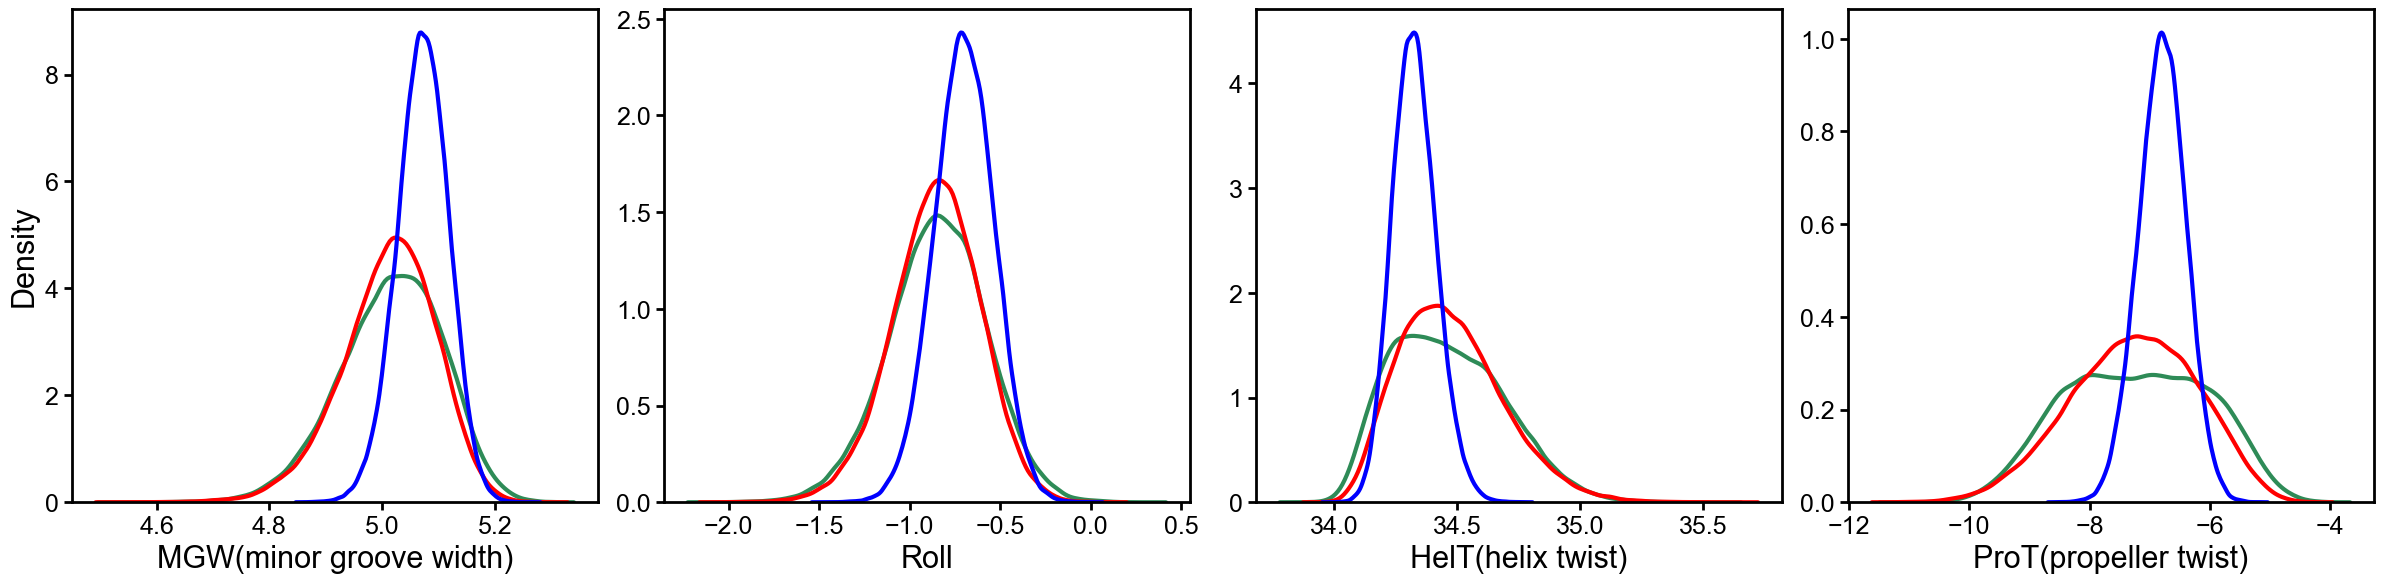

In [8]:
# --- 1. Global Configuration and Plotting Style ---
sns.set_theme(style="ticks")

base_path = '/dev_16T1/xlxiang/xxl_desktop/xlxiang/last_TargetGAN/sup_analysis' 
save_dir = './data_for_plot'
os.makedirs(save_dir, exist_ok=True)

# --- 2. Data Reading Function ---
def process_shape_files(shape_type, file_type, num_files=8):
    """
    Read data files for specific shape and type, return flattened array of means.
    """
    all_means = []
    folder_name = f"{file_type}_shape"
    
    for i in range(num_files):
        file_path = os.path.join(base_path, folder_name, str(i+1), shape_type)
        if not os.path.exists(file_path):
            continue
        try:
            with open(file_path, 'r') as f:
                lines = [line.strip() for line in f if not line.startswith('>')]
            current_seq_vals = []
            for idx, line in enumerate(lines, 1):
                vals = [float(x) for x in line.split(',') if x != 'NA']
                current_seq_vals.extend(vals)
                if idx % 11 == 0:
                    if current_seq_vals:
                        all_means.append(np.mean(current_seq_vals))
                    current_seq_vals = [] 
        except Exception:
            pass
    return np.array(all_means)

# --- 3. Plotting Loop ---
# Order: MGW, Roll, HelT, ProT (Matching the target image)
shape_types = ['MGW', 'Roll', 'HelT', 'ProT']
labels_map = {
    'MGW': 'MGW(minor groove width)',
    'Roll': 'Roll',
    'HelT': 'HelT(helix twist)',
    'ProT': 'ProT(propeller twist)'
}

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for idx, shape in enumerate(shape_types):
    print(f"Processing shape: {shape} ...")
    ax = axes[idx]
    
    # A. Read Data
    native_data = process_shape_files(shape, 'native', num_files=8)
    wgan_data = process_shape_files(shape, 'wgan', num_files=8)
    random_data = process_shape_files(shape, 'random', num_files=8)
    
    if len(native_data) == 0:
        continue

    # C. Plot KDE
    # Colors: Native=seagreen, GAN=red, Random=blue
    sns.kdeplot(native_data, color="seagreen", lw=3, label='Native', ax=ax)
    sns.kdeplot(wgan_data, color="red", lw=3, label='GAN', ax=ax)
    sns.kdeplot(random_data, color="blue", lw=3, label='Random', ax=ax)
    
    # D. Styling
    # Remove Title (Image does not have top titles)
    ax.set_title("")
    
    # X Label
    ax.set_xlabel(labels_map[shape], fontdict={'size': 22, 'family': 'Arial', 'color': 'black', 'weight': 'normal'})
    
    # Y Label (Only on the first plot)
    if idx == 0:
        ax.set_ylabel("Density", fontdict={'size': 22, 'family': 'Arial', 'color': 'black'})
        # Legend only on first, without frame
        # ax.legend(prop={'size': 16, 'family': 'Arial'}, frameon=False)
    else:
        ax.set_ylabel("")
    
    # Ticks
    ax.tick_params(axis='both', which='major', labelsize=18, width=2, length=6, colors='black')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname('Arial')

    # Spines (Borders) - Ensure TOP and RIGHT are preserved
    for spine_name in ['top', 'right', 'bottom', 'left']:
        spine = ax.spines[spine_name]
        spine.set_visible(True)
        spine.set_linewidth(2.0)
        spine.set_color('black')

plt.tight_layout()
    
# E. Save and Show
save_name = os.path.join(save_dir, 'all_shapes_combined_fixed.svg')
plt.savefig(save_name, dpi=600, bbox_inches='tight')
print(f"  -> Image saved: {save_name}")
plt.show()